# Plotting Code for EXP2: Hidden State Ablation Study

In [4]:
import numpy as np
import pickle as pkl
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json
os.chdir(r"""C:\Users\wassi\projects\gitrepos\ADALaS""")

In [6]:
FILENAMES = {
    "full_prop": r"data\test_results\alpaca\full_prop-1.3b_alpaca_27-08_18-16-38",
    "eval_full_prop": r"data\test_results\alpaca\eval_full_prop-1.3b_alpaca_28-08_14-17-42",
    "hidden_state": {
        2: r"data\test_results\alpaca\HS_2-1.3b_alpaca_27-08_18-52-12",
        4: r"data\test_results\alpaca\HS_4-1.3b_alpaca_27-08_19-29-02",
        6: r"data\test_results\alpaca\HS_6-1.3b_alpaca_27-08_20-06-02",
        10: r"data\test_results\alpaca\HS_10-1.3b_alpaca_27-08_20-43-17",
    },
    "fixed": {
        2: r"data\test_results\alpaca\fixed_2-1.3b_alpaca_27-08_21-20-06",
        4: r"data\test_results\alpaca\fixed_4-1.3b_alpaca_27-08_21-58-56",
        6: r"data\test_results\alpaca\fixed_6-1.3b_alpaca_27-08_22-36-18",
        10: r"data\test_results\alpaca\fixed_10-1.3b_alpaca_27-08_23-13-20",
    },
    "ULS": {
        12: r"data\test_results\alpaca\ULS_12L-1.3b_alpaca_28-08_02-12-08",
        8: r"data\test_results\alpaca\ULS_8L-1.3b_alpaca_28-08_02-48-04",
        6: r"data\test_results\alpaca\ULS_6L-1.3b_alpaca_28-08_03-24-02",
        4: r"data\test_results\alpaca\ULS_4L-1.3b_alpaca_28-08_04-01-03",
    },
    "eval_hidden_state": {
        2: r"data\test_results\alpaca\eval_HS_2-1.3b_alpaca_28-08_14-53-11",
        4: r"data\test_results\alpaca\eval_HS_4-1.3b_alpaca_28-08_15-30-22",
        6: r"data\test_results\alpaca\eval_HS_6-1.3b_alpaca_28-08_16-07-28",
        10: r"data\test_results\alpaca\eval_HS_10-1.3b_alpaca_28-08_16-44-36",
    },
}
shards = 5
alphas = [2,4,6,10]
data_dict = {}
data_dict["full_prop"] = [pkl.load(open(FILENAMES["full_prop"]+ f"\shard_{i}.pkl", "rb")) for i in range(shards)]
data_dict["eval_full_prop"] = [pkl.load(open(FILENAMES["eval_full_prop"]+ f"\shard_{i}.pkl", "rb")) for i in range(shards)]
data_dict["hidden_state"] = {}
for alpha in FILENAMES["hidden_state"]:
    data_dict["hidden_state"][alpha] = [pkl.load(open(FILENAMES["hidden_state"][alpha]+ f"\shard_{i}.pkl", "rb")) for i in range(shards)]
data_dict["fixed"] = {}
for alpha in FILENAMES["fixed"]:
    data_dict["fixed"][alpha] = [pkl.load(open(FILENAMES["fixed"][alpha]+ f"\shard_{i}.pkl", "rb")) for i in range(shards)]
data_dict["ULS"] = {}
for k in FILENAMES["ULS"]:
    data_dict["ULS"][k] = [pkl.load(open(FILENAMES["ULS"][k] + f"\shard_{i}.pkl", "rb")) for i in range(shards)]
data_dict["eval_hidden_state"] = {}
for alpha in FILENAMES["eval_hidden_state"]:
    data_dict["eval_hidden_state"][alpha] = [pkl.load(open(FILENAMES["eval_hidden_state"][alpha]+ f"\shard_{i}.pkl", "rb")) for i in range(shards)]


In [7]:
print(data_dict["eval_hidden_state"][4][0]["rouge_L_avg"])
print(data_dict["eval_hidden_state"][4][1]["rouge_L_avg"])
print(data_dict["eval_hidden_state"][4][2]["rouge_L_avg"])
print(data_dict["eval_hidden_state"][4][3]["rouge_L_avg"])
print(data_dict["eval_hidden_state"][4][4]["rouge_L_avg"])
print("mean")
print(np.mean([data_dict["eval_hidden_state"][4][i]["rouge_L_avg"] for i in range(shards)]))


0.3152732785286581
0.32534680018805995
0.32032462874736006
0.3185236894184396
0.3221758212906568
mean
0.3203288436346349


In [8]:
print(data_dict["full_prop"][0].keys())

dict_keys(['predictions', 'labels', 'inputs', 'rouge_1_avg', 'rouge_2_avg', 'rouge_L_avg', 'rouge_1_ind', 'rouge_2_ind', 'rouge_L_ind', 'layer_skip_percentages'])


In [10]:
full_prop_rougeL = [data_dict["full_prop"][i]["rouge_L_avg"] for i in range(shards)]
full_prop_perc_skip = [data_dict["full_prop"][i]["layer_skip_percentages"] for i in range(shards)]

eval_full_prop_rougeL = [data_dict["eval_full_prop"][i]["rouge_L_avg"] for i in range(shards)]
eval_full_prop_perc_skip = [data_dict["eval_full_prop"][i]["layer_skip_percentages"] for i in range(shards)]

HS_rougeL = [[data_dict["hidden_state"][alpha][i]["rouge_L_avg"] for i in range(shards)] for alpha in alphas]
HS_perc_skip = [[data_dict["hidden_state"][alpha][i]["layer_skip_percentages"] for i in range(shards)] for alpha in alphas]

fixed_rougeL = [[data_dict["fixed"][alpha][i]["rouge_L_avg"] for i in range(shards)] for alpha in alphas]
fixed_perc_skip = [[data_dict["fixed"][alpha][i]["layer_skip_percentages"] for i in range(shards)] for alpha in alphas]

ULS_rougeL = [[data_dict["ULS"][k][i]["rouge_L_avg"] for i in range(shards)] for k in FILENAMES["ULS"]]
ULS_perc_skip = [[data_dict["ULS"][k][i]["layer_skip_percentages"] for i in range(shards)] for k in FILENAMES["ULS"]]

eval_HS_rougeL = [[data_dict["eval_hidden_state"][alpha][i]["rouge_L_avg"] for i in range(shards)] for alpha in alphas]
eval_HS_perc_skip = [[data_dict["eval_hidden_state"][alpha][i]["layer_skip_percentages"] for i in range(shards)] for alpha in alphas]

In [11]:
print(np.mean(fixed_perc_skip[3], axis=0))
print(np.mean(np.mean(fixed_perc_skip[3], axis=0), axis=0))
print(fixed_rougeL[3])

print(np.mean(HS_perc_skip[3], axis=0))
print(np.mean(np.mean(HS_perc_skip[3], axis=0), axis=0))
print(HS_rougeL[3])

[0.         0.99243327 0.36619038 0.91815383 0.95799747 0.99866483
 0.99283333 0.93370029 0.84137849 0.75338959 0.70545079 0.71677492
 0.71820268 0.66751588 0.74000925 0.61262709 0.57802239 0.55245066
 0.39960853 0.36568225 0.53369963 0.87182845 0.99808031 0.        ]
0.6756122639837372
[np.float64(0.29840029668607304), np.float64(0.2966597690421383), np.float64(0.29931185203571975), np.float64(0.2992357785512961), np.float64(0.3020559608948423)]
[0.         0.89114268 0.82632717 0.88956276 0.93993411 0.95495982
 0.97797146 0.8692751  0.93878139 0.88708758 0.79273103 0.80265947
 0.85480986 0.8205529  0.77780113 0.69410984 0.39246635 0.47973609
 0.38376606 0.3668442  0.56339076 0.64471093 0.95273731 0.        ]
0.6958899162729195
[np.float64(0.2914771487514384), np.float64(0.2970760034505978), np.float64(0.29638338534772546), np.float64(0.28725260015962506), np.float64(0.2932090824680238)]


Text(14, 0.34670966549713444, 'Full model')

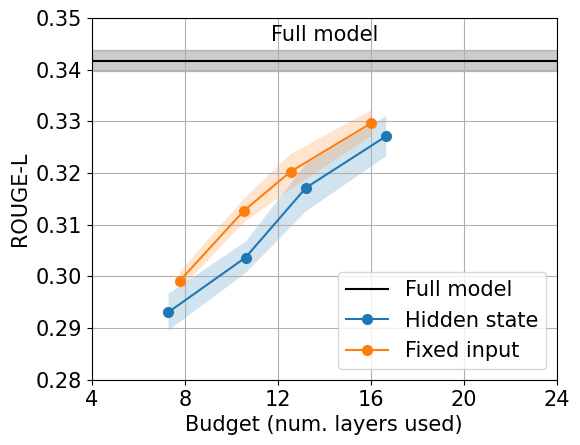

In [12]:
#plot RougeL against avg layer use
plt.figure(figsize=(6, 4.7))
plt.rcParams.update({'font.size': 15})
#plot with max-min error bars for each alpha
avg_rouge_full_prop = np.mean(full_prop_rougeL)
full_prop_std = np.std(full_prop_rougeL)
plt.axhline(y=avg_rouge_full_prop, color=(0,0,0), linestyle='-',label='Full model')
plt.fill_between([0,24], avg_rouge_full_prop-full_prop_std, avg_rouge_full_prop+full_prop_std, color=(0,0,0), alpha=0.2)

# avg_rouge_eval_full_prop = np.mean(eval_full_prop_rougeL)
# eval_full_prop_std = np.std(eval_full_prop_rougeL)
# plt.axhline(y=avg_rouge_eval_full_prop, color=(0,0,0), linestyle='--',label='Full model eval')
# plt.fill_between([0,24], avg_rouge_eval_full_prop-eval_full_prop_std, avg_rouge_eval_full_prop+eval_full_prop_std, color=(0,0,0), alpha=0.2)

avg_rouge_HS = [np.mean(HS_rougeL[i]) for i in range(len(alphas))]
std_rouge_HS = [np.std(HS_rougeL[i]) for i in range(len(alphas))]
perc_skip_HS = [np.mean(HS_perc_skip[i]) for i in range(len(alphas))]
perc_layer_use_HS = [(1 - perc_skip_HS[i])*24.0 for i in range(len(alphas))]
plt.plot(perc_layer_use_HS, avg_rouge_HS, label="Hidden state", marker='o',markersize=7)
plt.fill_between(perc_layer_use_HS, np.array(avg_rouge_HS)-np.array(std_rouge_HS), np.array(avg_rouge_HS)+np.array(std_rouge_HS), alpha=0.2)

avg_rouge_fixed = [np.mean(fixed_rougeL[i]) for i in range(len(alphas))]
std_rouge_fixed = [np.std(fixed_rougeL[i]) for i in range(len(alphas))]
perc_skip_fixed = [np.mean(fixed_perc_skip[i]) for i in range(len(alphas))]
perc_layer_use_fixed = [(1 - perc_skip_fixed[i])*24.0 for i in range(len(alphas))]
plt.plot(perc_layer_use_fixed, avg_rouge_fixed, label="Fixed input", marker='o',markersize=7)
plt.fill_between(perc_layer_use_fixed, np.array(avg_rouge_fixed)-np.array(std_rouge_fixed), np.array(avg_rouge_fixed)+np.array(std_rouge_fixed), alpha=0.2)


# avg_rouge_eval_HS = [np.mean(eval_HS_rougeL[i]) for i in range(len(alphas))]
# std_rouge_eval_HS = [np.std(eval_HS_rougeL[i]) for i in range(len(alphas))]
# perc_skip_eval_HS = [np.mean(eval_HS_perc_skip[i]) for i in range(len(alphas))]
# perc_layer_use_eval_HS = [(1 - perc_skip_eval_HS[i])*24.0 for i in range(len(alphas))]
# plt.plot(perc_layer_use_eval_HS, avg_rouge_eval_HS, label="Hidden state eval", marker='o',markersize=7)
# plt.fill_between(perc_layer_use_eval_HS, np.array(avg_rouge_eval_HS)-np.array(std_rouge_eval_HS), np.array(avg_rouge_eval_HS)+np.array(std_rouge_eval_HS), alpha=0.2)

# avg_rouge_ULS = [np.mean(ULS_rougeL[i]) for i in range(len(FILENAMES["ULS"]))]
# std_rouge_ULS = [np.std(ULS_rougeL[i]) for i in range(len(FILENAMES["ULS"]))]
# perc_skip_ULS = [np.mean(ULS_perc_skip[i]) for i in range(len(FILENAMES["ULS"]))]
# perc_layer_use_ULS = [(1 - perc_skip_ULS[i])*24.0 for i in range(len(FILENAMES["ULS"]))]
# plt.plot(perc_layer_use_ULS, avg_rouge_ULS, label="ULS", marker='o',markersize=7)
# plt.fill_between(perc_layer_use_ULS, np.array(avg_rouge_ULS)-np.array(std_rouge_ULS), np.array(avg_rouge_ULS)+np.array(std_rouge_ULS), alpha=0.2)

#plt.plot(HS_layer_use, HS_rouge, label="Hidden state eval", marker='o',markersize=7)
#plt.plot(fixed_layer_use, fixed_rouge, label="Fixed input eval", marker='o',markersize=7)
# # plt.plot(ULS_layer_use, ULS_rouge, label="ULS eval", marker='o',markersize=7)

plt.xlim(4,24)
plt.xticks(np.arange(4, 25, 4))
plt.ylim(0.28,0.35)
plt.grid()
plt.ylabel("ROUGE-L")
plt.xlabel("Budget (num. layers used)")
plt.legend()
#add text "full model"
plt.text(14, avg_rouge_full_prop + 0.005, "Full model", fontsize=15, ha='center', va='center')
#save as pdf
# plt.savefig(r"data\eval_results\alpaca\layer_use_rouge.pdf", bbox_inches='tight')

In [13]:
#load JSON results

FILENAMES = {
    "hidden_state" : r"data\eval_results\alpaca\hidden_state_res.json",
    "fixed": r"data\eval_results\alpaca\fixed_res.json",
    "ULS": r"data\eval_results\alpaca\ULS_res.json",
}
alphas = [2,4,6,10]
ULS_layers = [24,12,8,6,4]
data_dict = {}
for key in FILENAMES:
    with open(FILENAMES[key], 'r') as f:
        data_dict[key] = json.load(f)

print(data_dict["hidden_state"].keys())
print(data_dict["hidden_state"]["HS_2"].keys())

FileNotFoundError: [Errno 2] No such file or directory: 'data\\eval_results\\alpaca\\hidden_state_res.json'

In [ ]:
HS_rouge = [data_dict["hidden_state"][f"HS_{i}"]["rougeL"] for i in alphas]
HS_loss = [data_dict["hidden_state"][f"HS_{i}"]["loss"] for i in alphas]
HS_perc_skip = [data_dict["hidden_state"][f"HS_{i}"]["perc_skip"] for i in alphas]
HS_layer_use = [(1-s)*24 for s in HS_perc_skip]

fixed_rouge = [data_dict["fixed"][f"fixed_{i}"]["rougeL"] for i in alphas]
fixed_loss = [data_dict["fixed"][f"fixed_{i}"]["loss"] for i in alphas]
fixed_perc_skip = [data_dict["fixed"][f"fixed_{i}"]["perc_skip"] for i in alphas]
fixed_layer_use = [(1-s)*24 for s in fixed_perc_skip]

ULS_rouge = [data_dict["ULS"][f"ULS_{i}"]["rougeL"] for i in ULS_layers]
ULS_loss = [data_dict["ULS"][f"ULS_{i}"]["loss"] for i in ULS_layers]
ULS_perc_skip = [data_dict["ULS"][f"ULS_{i}"]["perc_skip"] for i in ULS_layers]
ULS_layer_use = [(1-s)*24 for s in ULS_perc_skip]

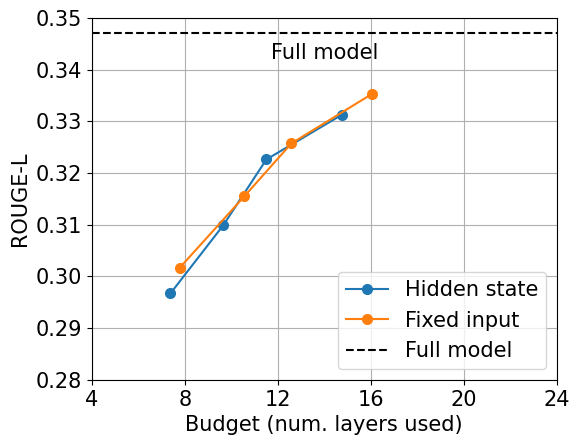

In [ ]:
#plot RougeL against avg layer use
plt.figure(figsize=(6, 4.7))
plt.rcParams.update({'font.size': 15})
plt.plot(HS_layer_use, HS_rouge, label="Hidden state", marker='o',markersize=7)
plt.plot(fixed_layer_use, fixed_rouge, label="Fixed input", marker='o',markersize=7)
plt.axhline(y=data_dict["ULS"]["ULS_24"]["rougeL"], color=(0,0,0), linestyle='--',label='Full model')
plt.xlim(4,24)
plt.xticks(np.arange(4, 25, 4))
plt.ylim(0.28,0.35)
plt.grid()
plt.ylabel("ROUGE-L")
plt.xlabel("Budget (num. layers used)")
plt.legend()
#add text "full model"
plt.text(14, data_dict["ULS"]["ULS_24"]["rougeL"]-0.005, 'Full model', ha='center')
#save as pdf
plt.savefig(r"data\eval_results\alpaca\layer_use_rouge.pdf", bbox_inches='tight')


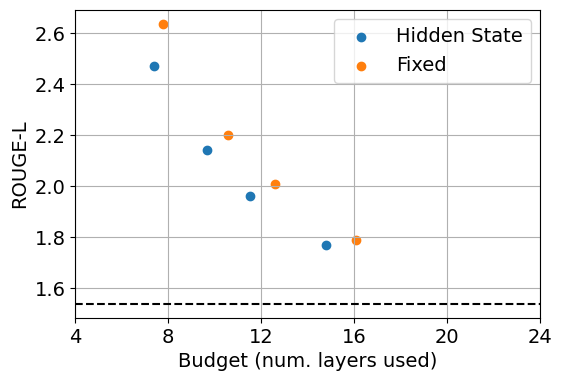

In [ ]:
#plot Loss against avg layer use
plt.figure(figsize=(6, 4))
plt.rcParams.update({'font.size': 14})
plt.scatter(HS_layer_use, HS_loss, label="Hidden State")
plt.scatter(fixed_layer_use, fixed_loss, label="Fixed")
plt.axhline(y=data_dict["ULS"]["ULS_24"]["loss"], color=(0,0,0), linestyle='--')
plt.xlim(4,24)
plt.xticks(np.arange(4, 25, 4))
plt.grid()
plt.ylabel("ROUGE-L")
plt.xlabel("Budget (num. layers used)")
plt.legend()